In [1]:
# --- SETUP: IMPORTS AND CONFIGURATION ---

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from scipy import stats
from scipy.optimize import minimize
from PyLTSpice import SimRunner, SpiceEditor
from PyLTSpice.log.ltsteps import LTSpiceLogReader

# --- Paths ---
PROJECT_ROOT       = Path("..").resolve()
PROJECT_SIM_FOLDER = PROJECT_ROOT / "res" / "srcs" / "project-01"
OUTPUT_SIM_FOLDER  = PROJECT_ROOT / "notebooks" / "output" / "project-01" / "sim"
OUTPUT_FIG_FOLDER  = PROJECT_ROOT / "notebooks" / "output" / "project-01" / "fig"
OUTPUT_SIM_FOLDER.mkdir(parents=True, exist_ok=True)
OUTPUT_FIG_FOLDER.mkdir(parents=True, exist_ok=True)

# --- LTspice runner (update path to match your installation) ---
LTSPICE_EXE = r"D:\Softwares\ADI\LTspiceXVII\XVIIx64.exe"
runner = SimRunner(
    output_folder=OUTPUT_SIM_FOLDER, # pyright: ignore[reportArgumentType]
    simulator=LTSPICE_EXE,
    parallel_sims=4,
)

# --- Project constants ---
VDD = 1.0  # supply voltage [V]

# --- Helper functions ---
def _get_measure(reader: LTSpiceLogReader, name: str) -> float:
    """Scalar measurement accessor that handles both return types of LTSpiceLogReader.

    For non-stepped simulations PyLTSpice may return either a bare scalar or a
    single-element sequence depending on the library version; this helper
    normalises both cases so Step 05 code is version-agnostic.
    """
    val = reader[name]
    return float(val[0]) if hasattr(val, "__len__") else float(val)

## Step 01 – Minimum Inverter PMOS Sizing

Find the optimal PMOS channel width `wp` that balances the rise and fall
propagation delays of the minimum-sized inverter, and extract the intrinsic
delay `τ₀` of the balanced inverter driving **no capacitive load** (output
connected only to the measurement probe).

Both quantities propagate to all subsequent calibration steps:
- `wp_rounded` sets the sizing reference for every other netlist
- `delay_crossover` (= `τ₀`) is the unloaded delay anchor used by the
  delay model in Step 04 and **must not be re-measured** in later steps


In [2]:
# --- STEP 01.1: RUN PMOS SIZING SWEEP ---

print("Running PMOS sizing sweep...")
netlist_sizing = SpiceEditor(
    PROJECT_SIM_FOLDER / "01-PMOS_sizing" / "inverter_min_PMOS-sizing.asc"
)
_, log_sizing = runner.run_now(netlist_sizing)
print(f"Done.  Log: {log_sizing}")

Running PMOS sizing sweep...
Done.  Log: C:\Users\stefa\Workspace\01-UNICAL\Low_power-projects\notebooks\output\project-01\sim\inverter_min_PMOS-sizing_1.log


In [3]:
# --- STEP 01.2: EXTRACT RISE/FALL PROPAGATION DELAYS ---
# The netlist sweeps wp with .step param wp 120-360nm in steps of 10nm (25 steps).

data_sizing = LTSpiceLogReader(log_sizing.as_posix()) # pyright: ignore[reportOptionalMemberAccess]

tp_rise = np.array(data_sizing["delay_rise"])  # t_pLH [s]
tp_fall = np.array(data_sizing["delay_fall"])  # t_pHL [s]
n_steps = len(tp_rise)

WP_START_NM, WP_STEP_NM = 120, 10
wp_sweep_nm = WP_START_NM + np.arange(n_steps) * WP_STEP_NM

df_sizing = pd.DataFrame({
    "wp [nm]":              wp_sweep_nm,
    "Delay (rise)":         tp_rise,
    "Delay (fall)":         tp_fall,
    "Delay (avg)":          (tp_rise + tp_fall) / 2,
})

print(f"Extracted {n_steps} steps  "
      f"(wp: {wp_sweep_nm[0]:.0f}-{wp_sweep_nm[-1]:.0f}nm @ 10nm)")
df_sizing.head(n_steps)

Extracted 25 steps  (wp: 120-360nm @ 10nm)


,wp [nm],Delay (rise),Delay (fall),Delay (avg)
0,120,9.337490e-12,6.187970e-12,7.762730e-12
1,130,9.106990e-12,6.425060e-12,7.766025e-12
2,140,8.915900e-12,6.644580e-12,7.780240e-12
3,150,8.667560e-12,6.853540e-12,7.760550e-12
4,160,8.453710e-12,7.050840e-12,7.752275e-12
5,170,8.355360e-12,7.292620e-12,7.823990e-12
6,180,8.114810e-12,7.577560e-12,7.846185e-12
7,190,8.092880e-12,7.839680e-12,7.966280e-12
8,200,7.895800e-12,8.083750e-12,7.989775e-12
9,210,7.765290e-12,8.313600e-12,8.039445e-12


In [4]:
# --- STEP 01.3: FIND OPTIMAL WP AND EXTRACT τ₀ ---
# Optimal wp: the step where |t_pLH - t_pHL| is minimised (delay crossover).
# τ₀ = average propagation delay at that point = intrinsic unloaded delay.

crossover_idx   = np.argmin(np.abs(df_sizing["Delay (rise)"] - df_sizing["Delay (fall)"]))
wp_rounded      = int(df_sizing.loc[crossover_idx, "wp [nm]"])          # [nm]      # pyright: ignore[reportCallIssue, reportArgumentType]
delay_crossover = float(df_sizing.loc[crossover_idx, "Delay (avg)"])    # τ₀ [s]    # pyright: ignore[reportCallIssue, reportArgumentType]

print(f"Optimal PMOS width: wp = {wp_rounded} nm")
print(f"Intrinsic delay:    τ₀ = {delay_crossover * 1e12:.4f} ps")

Optimal PMOS width: wp = 200 nm
Intrinsic delay:    τ₀ = 7.9898 ps


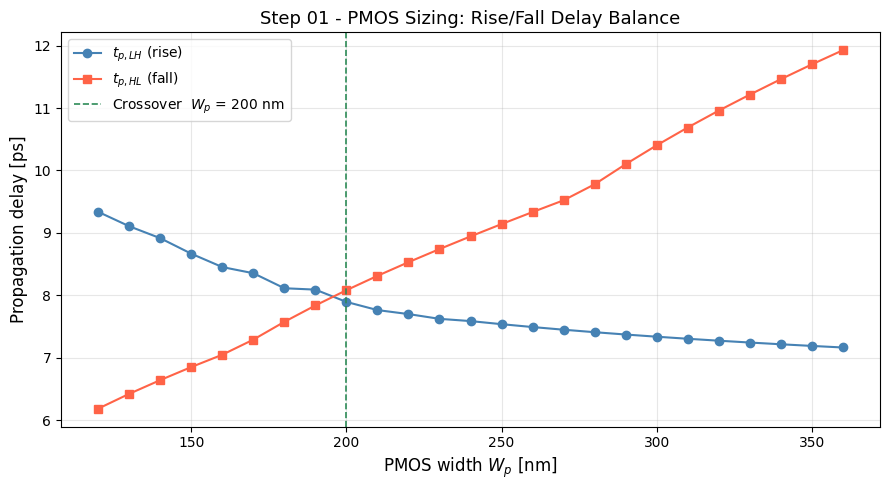

In [5]:
# --- STEP 01.4: PLOT RISE/FALL DELAYS VS WP ---

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(df_sizing["wp [nm]"], df_sizing["Delay (rise)"] * 1e12, "o-",
        color="steelblue", label=r"$t_{p,LH}$ (rise)")
ax.plot(df_sizing["wp [nm]"], df_sizing["Delay (fall)"] * 1e12, "s-",
        color="tomato",    label=r"$t_{p,HL}$ (fall)")
ax.axvline(wp_rounded, color="seagreen", linestyle="--", linewidth=1.2,
           label=f"Crossover  $W_p$ = {wp_rounded} nm")

ax.set_xlabel("PMOS width $W_p$ [nm]", fontsize=12)
ax.set_ylabel("Propagation delay [ps]", fontsize=12)
ax.set_title("Step 01 - PMOS Sizing: Rise/Fall Delay Balance", fontsize=13)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(OUTPUT_FIG_FOLDER / "step01_pmos_sizing.png", dpi=300)
plt.show()

## Step 02 – Technology Model Calibration

Extract the four calibration parameters from dedicated LTspice testbenches.

| Parameter | Symbol | Description |
|-----------|--------|-------------|
| Input gate capacitance | $C_{in,0}$ | Gate capacitance of the unit-width inverter |
| Drain diffusion capacitance | $C_d$ | Drain parasitic of the unit-width inverter |
| Energy ratio | $\gamma_E = C_d / C_{in,0}$ | Drain-to-input capacitance ratio |
| Delay scaling factor | $\gamma_D$ | Controls how delay grows with fan-out load |

`τ₀` (= `delay_crossover` from **Step 01**) is the intrinsic unloaded delay and
is reused directly.


In [ ]:
# --- STEP 02.1: RUN CAPACITANCE EXTRACTION SIMULATIONS ---
# inverter_Cin.asc – capacitance model:  C_total_cin(S) = Cd + S·Cin0
#   The fixed term Cd is the drain diffusion parasitic; S·Cin0 is the
#   scaled gate input capacitance.
#
# inverter_Cd.asc  – capacitance model:  C_total_cd(S)  = S·(Cd + Cin0)
#   Both components scale with S here; used as a cross-check.

print("Running inverter_Cin simulation...")
netlist_cin = SpiceEditor(PROJECT_SIM_FOLDER / "02-gamma_E" / "inverter_Cin.asc")
netlist_cin.set_parameter("wp", f"{wp_rounded}n")
_, log_cin = runner.run_now(netlist_cin)
print(f"Done.  Log: {log_cin}")

print("Running inverter_Cd simulation...")
netlist_cd = SpiceEditor(PROJECT_SIM_FOLDER / "02-gamma_E" / "inverter_Cd.asc")
netlist_cd.set_parameter("wp", f"{wp_rounded}n")
_, log_cd = runner.run_now(netlist_cd)
print(f"Done.  Log: {log_cd}")

In [ ]:
# --- STEP 02.2: PARSE CAPACITANCE MEASUREMENTS ---
# The netlist sweeps S with .step param S 1-10x in steps of 0.25x.

data_cin = LTSpiceLogReader(log_cin.as_posix()) # pyright: ignore[reportOptionalMemberAccess]
data_cd  = LTSpiceLogReader(log_cd.as_posix()) # pyright: ignore[reportOptionalMemberAccess]

C_total_cin = np.array(data_cin["energy"])
C_total_cd  = np.array(data_cd["energy"])
n_steps = len(C_total_cin)

S_START, S_STEP = 1, 0.25
S_values = S_START + np.arange(n_steps) * S_STEP

df_calib = pd.DataFrame({
    "S":                S_values,
    "Cin (tot) [F]":    C_total_cin,
    "Cd (tot) [F]":     C_total_cd,
})

print(f"Capacitance data: {len(df_calib)} S-steps "
      f"(S = {S_values[0]:.0f}-{S_values[-1]:.0f}x @ 0.25x)")
df_calib.head(len(S_values))

In [ ]:
# --- STEP 02.3: EXTRACT Cin0, Cd, AND γE VIA LINEAR REGRESSION ---
# Primary extraction from inverter_Cin model:
#   C_total_cin(S) = Cd + S·Cin0  =>  linregress(S, C_cin): slope=Cin0, intercept=Cd
#
# Using ALL S-steps (not a single point) makes extraction robust to
# individual simulation noise — this is the key fix vs. the single-point approach.
#
# Cross-check from inverter_Cd model:
#   C_total_cd(S) = S·(Cd + Cin0)  =>  linregress(S, C_cd): slope = Cd + Cin0

slope_cin, Cd, r_cin, _, _ = stats.linregress(df_calib["S"], df_calib["Cin (tot) [F]"])
Cin0 = slope_cin  # gate capacitance per unit-width inverter [F]

# Physical sanity check: drain capacitance must be positive
assert Cd > 0, ( # pyright: ignore[reportOperatorIssue]
    f"Unphysical result: Cd = {Cd:.4e} F (expected > 0). "
    "Verify inverter_Cin.asc measurement setup and simulation convergence."
)

# Cross-check via inverter_Cd regression
slope_cd, _, r_cd, _, _ = stats.linregress(df_calib["S"], df_calib["Cd (tot) [F]"])

gamma_E = Cd / Cin0 # pyright: ignore[reportOperatorIssue]

print("=" * 60)
print("CAPACITANCE EXTRACTION  (inverter_Cin - all S steps)")
print("=" * 60)
print(f"  Cin0 = {Cin0 * 1e15:.4f} fF           (R² = {r_cin**2:.5f})") # pyright: ignore[reportOperatorIssue]
print(f"  Cd   = {Cd   * 1e15:.4f} fF") # pyright: ignore[reportOperatorIssue]
print(f"  γE   = Cd / Cin0 = {gamma_E:.4f}")
print()
print("  Cross-check (inverter_Cd regression):")
print(f"    Cd + Cin0  (direct):    {(Cd + Cin0) * 1e15:.4f} fF") # pyright: ignore[reportOperatorIssue]
print(f"    Cd + Cin0  (fitting):   {slope_cd    * 1e15:.4f} fF     (R² = {r_cd**2:.5f})") # pyright: ignore[reportOperatorIssue]
print("=" * 60)

In [ ]:
# --- STEP 02.4: RUN γD CALIBRATION SIMULATION ---
# inverter_gamma_D.asc sweeps the load scaling factor S and measures the
# propagation delay at each step, used to calibrate the delay model slope.

print("Running inverter_gamma_D simulation...")
netlist_gd = SpiceEditor(PROJECT_SIM_FOLDER / "03-gamma_D" / "inverter_gamma_D.asc")
netlist_gd.set_parameter("wp", f"{wp_rounded}n")
_, log_gd = runner.run_now(netlist_gd)
print(f"Done.  Log: {log_gd}")

In [ ]:
# --- STEP 02.5: EXTRACT γD FROM DELAY-VS-FANOUT REGRESSION ---
# Delay model:  Δt(S) = τ₀·(1 + S/γD)
#   =>  Δt/τ₀ - 1 = (1/γD)·(S - 1)
# Linear regression of  y = Δt/τ₀ - 1  vs  x = S - 1  gives slope = 1/γD.
#
# τ₀ reused from Step 01 (delay_crossover); NOT re-derived here.

tau0 = delay_crossover  # intrinsic unloaded delay [s] – anchor from Step 01

data_gd = LTSpiceLogReader(log_gd.as_posix()) # pyright: ignore[reportOptionalMemberAccess]

tp_avg_gd = np.array(data_gd["delay"])
S_gd      = np.arange(1, len(tp_avg_gd) + 1, dtype=float)

df_tau = pd.DataFrame({
    "S":       S_gd,
    "delay_s": tp_avg_gd,
    "x":       S_gd - 1,
    "y":       tp_avg_gd / tau0 - 1,
})

slope_gamma, _, r_gd, _, _ = stats.linregress(df_tau["x"], df_tau["y"])
gamma_D = 1.0 / slope_gamma # delay scaling factor  # pyright: ignore[reportOperatorIssue]

print("=" * 60)
print("γD EXTRACTION")
print("=" * 60)
print(f"  τ₀   (Step 01):   {tau0 * 1e12:.4f} ps")
print(f"  1/γD (slope):     {slope_gamma:.4f}")
print(f"  γD:               {gamma_D:.4f}       (R² = {r_gd**2:.5f})") # pyright: ignore[reportOperatorIssue]
print("=" * 60)

In [ ]:
# --- STEP 02.6: CALIBRATION SUMMARY ---

calibration_params = {
    "wp_rounded": wp_rounded,   # optimal PMOS width [nm]
    "Cin0":       Cin0,         # gate capacitance per unit inverter [F]
    "Cd":         Cd,           # drain diffusion capacitance [F]
    "gamma_E":    gamma_E,      # Cd / Cin0
    "gamma_D":    gamma_D,      # delay scaling factor
    "tau0":       tau0,         # intrinsic unloaded delay [s]
}

print("=" * 60)
print("CALIBRATED MODEL PARAMETERS  (Step 02 Summary)")
print("=" * 60)
print(f"  wp_rounded :  {wp_rounded} nm")
print(f"  Cin0       :  {Cin0    * 1e15:.4f} fF") # pyright: ignore[reportOperatorIssue]
print(f"  Cd         :  {Cd      * 1e15:.4f} fF") # pyright: ignore[reportOperatorIssue]
print(f"  gamma_E    :  {gamma_E:.4f}")
print(f"  gamma_D    :  {gamma_D:.4f}")
print(f"  tau0       :  {tau0    * 1e12:.4f} ps")
print("=" * 60)


## Step 03 – Empirical Pareto Curve (Monte Carlo Simulation)

Explore the design space defined by the scaling factors `S2` (stage 2) and
`S3` (stage 3) relative to the minimum inverter, using a **1000-run Monte
Carlo sweep** in LTspice.  `S2` and `S3` are drawn as uniform random variables
via the LTspice `mc()` function, re-seeded at each `.step param run` iteration.

The final stage always drives a fixed capacitive load of `50×` the minimum
inverter.  For each run, total propagation **delay** and total dynamic
**energy** are measured and collected into the design-space cloud.

The **empirical Pareto frontier** (minimum energy at each delay) is extracted
from this cloud and used as the reference for model validation in Step 05.


In [ ]:
# --- STEP 03.1: RUN MONTE CARLO SIMULATION (1000 RUNS) ---
# A single LTspice invocation handles all 1000 .step iterations internally.

print("Running buffer Monte Carlo simulation (1000 runs)...")
netlist_mc = SpiceEditor(
    PROJECT_SIM_FOLDER / "04-montecarlo" / "buffer_montecarlo.asc"
)
netlist_mc.set_parameter("wp", f"{wp_rounded}n")
_, log_mc = runner.run_now(netlist_mc)
print(f"Done.  Log: {log_mc}")


In [ ]:
# --- STEP 03.2: EXTRACT MONTE CARLO MEASUREMENTS ---
# Energy decomposition (matches the energy model in Step 04):
#   energy_2   – stage 2 charging event (IN rising edge, measured on Vdd_2)
#   energy_1_3 – stages 1 + 3 charging events (IN falling edge, measured on Vdd_1_3)
# On each input edge exactly one half of the stages charge (the others discharge);
# summing the two complementary measurements reconstructs the full switching energy.

data_mc = LTSpiceLogReader(log_mc.as_posix())

df_mc = pd.DataFrame({
    "S2":           np.array(data_mc["s_2"]),
    "S3":           np.array(data_mc["s_3"]),
    "delay_s":      np.array(data_mc["delay"]),
    "energy_2_J":   np.array(data_mc["energy_2"]),
    "energy_1_3_J": np.array(data_mc["energy_1_3"]),
})
df_mc["energy_total_J"] = df_mc["energy_2_J"] + df_mc["energy_1_3_J"]

# Drop non-converged runs before any further processing
df_mc = df_mc.dropna().reset_index(drop=True)

print(f"Valid runs:  {len(df_mc)} / {data_mc.step_count}")
print(f"S2 range:    {df_mc['S2'].min():.2f} – {df_mc['S2'].max():.2f}")
print(f"S3 range:    {df_mc['S3'].min():.2f} – {df_mc['S3'].max():.2f}")
df_mc.head()


In [ ]:
# --- STEP 03.3: EXTRACT EMPIRICAL PARETO FRONTIER ---
# A point is Pareto-optimal iff no other run achieves both lower delay AND
# lower-or-equal energy.  Sorting by delay and tracking the running minimum
# energy efficiently identifies the non-dominated subset.

df_mc_sorted   = df_mc.sort_values("delay_s").reset_index(drop=True)
running_min_E  = df_mc_sorted["energy_total_J"].cummin()
df_pareto_empirical = (
    df_mc_sorted[df_mc_sorted["energy_total_J"] <= running_min_E]
    .reset_index(drop=True)
)

print(f"Empirical Pareto frontier: {len(df_pareto_empirical)} points "
      f"(out of {len(df_mc)} valid runs)")
df_pareto_empirical[["S2", "S3", "delay_s", "energy_total_J"]]


In [ ]:
# --- STEP 03.4: PLOT DESIGN SPACE AND EMPIRICAL FRONTIER ---

fig, ax = plt.subplots(figsize=(10, 6))
ax.scatter(df_mc["delay_s"] * 1e12, df_mc["energy_total_J"] * 1e15,
           s=12, alpha=0.35, color="steelblue", label="Monte Carlo runs")
ax.plot(df_pareto_empirical["delay_s"] * 1e12,
        df_pareto_empirical["energy_total_J"] * 1e15,
        "o-", color="tomato", markersize=5, linewidth=1.5,
        label="Empirical Pareto frontier")

ax.set_xlabel("Total propagation delay (ps)", fontsize=12)
ax.set_ylabel("Total energy (fJ)", fontsize=12)
ax.set_title("Step 03 – Energy–Delay Design Space  (Monte Carlo, 1000 runs)",
             fontsize=13)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(OUTPUT_FIG_FOLDER / "step03_pareto_empirical.png", dpi=300)
plt.show()


## Step 04 – Theoretical Pareto Curve (Sensitivity Analysis)

Derive the **theoretical Pareto curve** by solving, for each delay target $D_t$
spanning the feasible range $[D_{min},\, D_{max}]$, the constrained optimisation:

$$\min_{S_2,\,S_3}\; E(S_2, S_3) \quad \text{s.t.} \quad D(S_2, S_3) \leq D_t,
\quad S_2 \geq 1,\quad S_3 \geq 1$$

The models are calibrated with the parameters from Step 02:

$$D(S_2, S_3) = \tau_0\!\left(1 + \frac{S_2}{\gamma_D}\right)
+ \tau_0\!\left(1 + \frac{S_3}{\gamma_D S_2}\right)
+ \tau_0\!\left(1 + \frac{50}{\gamma_D S_3}\right)$$

$$E(S_2, S_3) = V_{DD}^2\,C_{in,0}\bigl[\gamma_E + S_2(1+\gamma_E)
+ S_3(1+\gamma_E) + 50\bigr]$$

The solver (`scipy SLSQP`) is warm-started from each solution to stabilise
convergence across the curve.


In [ ]:
# --- STEP 04.1: DEFINE CALIBRATED ENERGY AND DELAY MODELS ---
# CL = 50·Cin0: fixed capacitive load of the last stage (design constraint).

C_LOAD_FACTOR = 50
CL = C_LOAD_FACTOR * Cin0


def buffer_delay(S2: float, S3: float) -> float:
    """Total propagation delay of the three-stage buffer [s]  (Eq. 2.1)."""
    return (
        tau0 * (1.0 + S2 / gamma_D)
        + tau0 * (1.0 + S3 / (gamma_D * S2))
        + tau0 * (1.0 + C_LOAD_FACTOR / (gamma_D * S3))
    )


def buffer_energy(S2: float, S3: float) -> float:
    """Total dynamic energy dissipated by the three-stage buffer [J]  (Eq. 2.2)."""
    return VDD**2 * (
        gamma_E * Cin0
        + S2 * Cin0 * (1.0 + gamma_E)
        + S3 * Cin0 * (1.0 + gamma_E)
        + CL
    )


In [ ]:
# --- STEP 04.2: DETERMINE FEASIBLE DELAY RANGE ---
# D_max: unscaled buffer (S2 = S3 = 1) — min energy / slowest configuration.
# D_min: minimum achievable delay, found by minimising buffer_delay subject
#        only to the S >= 1 sizing floor.

S_BOUNDS = [(1.0, None), (1.0, None)]   # S2, S3 >= 1 (minimum inverter)

D_max = buffer_delay(1.0, 1.0)

res_fastest = minimize(
    lambda x: buffer_delay(x[0], x[1]),
    x0=[5.0, 15.0],
    bounds=S_BOUNDS,
    method="SLSQP",
)
assert res_fastest.success, (
    f"D_min optimisation failed: {res_fastest.message}. "
    "Check model parameters and initial guess."
)
D_min          = res_fastest.fun
S2_min, S3_min = res_fastest.x

print(f"D_max  (S2 = S3 = 1):            {D_max * 1e12:.2f} ps")
print(f"D_min  (S2 = {S2_min:.2f}, S3 = {S3_min:.2f}):  {D_min * 1e12:.2f} ps")


In [ ]:
# --- STEP 04.3: SWEEP DELAY TARGETS – MINIMISE ENERGY (SLSQP) ---
# The delay constraint is formulated as an inequality (D(S2,S3) <= D_target)
# for numerical robustness; it is active at every optimum because energy
# decreases monotonically as S2, S3 shrink.
# Warm-starting each solve from the previous solution (continuation) exploits
# the geometric continuity of the Pareto curve and speeds up convergence.

N_TARGETS    = 25
delay_targets = np.linspace(D_min * 1.01, D_max, N_TARGETS)

theoretical_results = []
x0 = [S2_min, S3_min]   # warm-start from the fastest feasible point

for D_target in delay_targets:
    res = minimize(
        lambda x: buffer_energy(x[0], x[1]),
        x0=x0,
        bounds=S_BOUNDS,
        constraints=[{
            "type": "ineq",
            "fun": lambda x, Dt=D_target: Dt - buffer_delay(x[0], x[1]),
        }],
        method="SLSQP",
    )
    if not res.success:
        print(f"  Warning: did not converge for "
              f"D_target = {D_target * 1e12:.1f} ps  ({res.message})")
        continue

    S2_opt, S3_opt = res.x
    theoretical_results.append({
        "D_target_s": D_target,
        "S2":         S2_opt,
        "S3":         S3_opt,
        "delay_s":    buffer_delay(S2_opt, S3_opt),
        "energy_J":   buffer_energy(S2_opt, S3_opt),
    })
    x0 = res.x   # warm-start next target from this solution

df_pareto_theoretical = pd.DataFrame(theoretical_results)
print(f"Theoretical Pareto curve: "
      f"{len(df_pareto_theoretical)} / {N_TARGETS} targets converged")
df_pareto_theoretical[["S2", "S3", "delay_s", "energy_J"]]


In [ ]:
# --- STEP 04.4: PLOT THEORETICAL PARETO CURVE ---

fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(df_pareto_theoretical["delay_s"] * 1e12,
        df_pareto_theoretical["energy_J"] * 1e15,
        "o-", color="darkorange", markersize=5, linewidth=1.5,
        label="Theoretical Pareto curve")

ax.set_xlabel("Total propagation delay (ps)", fontsize=12)
ax.set_ylabel("Total energy (fJ)", fontsize=12)
ax.set_title("Step 04 – Theoretical Energy–Delay Pareto Curve  "
             "(sensitivity analysis)", fontsize=13)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(OUTPUT_FIG_FOLDER / "step04_pareto_theoretical.png", dpi=300)
plt.show()


## Step 05 – Model Verification (LTspice Validation)

Simulate in LTspice each `(S2, S3)` pair produced by the sensitivity analysis
in Step 04 and compare the measured `(delay, energy)` against both the
**empirical frontier** (Step 03) and the **theoretical curve** (Step 04).

`buffer.asc` has no `.step` directive: `S2`, `S3`, and `wp` are scalar
parameters set per-run from Python, so each configuration requires its own
LTspice invocation.

The comparison assesses:
- **Convexity** – whether the verified curve has the same qualitative
  energy–delay trade-off shape as the empirical frontier.
- **Quantitative offset** – any systematic energy deviation (typically an
  underestimate by the analytical model) attributable to the linear
  $C_{in},\, C_d \propto W$ approximation.


In [ ]:
# --- STEP 05.1: RUN LTSPICE FOR EACH THEORETICAL PARETO POINT ---
# A fresh SpiceEditor instance is created per run to prevent parameter
# leakage between consecutive simulations.
# _get_measure() normalises LTSpiceLogReader's return type (scalar vs list)
# for non-stepped netlists across PyLTSpice versions.

netlist_path = PROJECT_SIM_FOLDER / "06-verification" / "buffer.asc"
verification_results = []

print(f"Running {len(df_pareto_theoretical)} verification simulations...")
for i, row in df_pareto_theoretical.iterrows():
    netlist_verif = SpiceEditor(netlist_path)
    netlist_verif.set_parameter("wp", f"{wp_rounded}n")
    netlist_verif.set_parameter("S2", f"{row['S2']:.6f}")
    netlist_verif.set_parameter("S3", f"{row['S3']:.6f}")
    _, log_verif = runner.run_now(netlist_verif)

    data_verif = LTSpiceLogReader(log_verif.as_posix())  # pyright: ignore[reportOptionalMemberAccess]
    delay_meas  = _get_measure(data_verif, "delay")
    energy_meas = (
        _get_measure(data_verif, "energy_2")
        + _get_measure(data_verif, "energy_1_3")
    )

    verification_results.append({
        "S2":                   row["S2"],
        "S3":                   row["S3"],
        "delay_s":              delay_meas,
        "energy_total_J":       energy_meas,
        "energy_theoretical_J": row["energy_J"],
    })
    print(f"  [{i + 1:>2}/{len(df_pareto_theoretical)}]  "
          f"S2={row['S2']:.2f}  S3={row['S3']:.2f}  →  "
          f"delay={delay_meas * 1e12:.1f} ps  "
          f"energy={energy_meas * 1e15:.2f} fJ")

# Drop any non-converged run before comparison
df_pareto_verified = (
    pd.DataFrame(verification_results)
    .dropna()
    .reset_index(drop=True)
)
print(f"\nVerification complete: {len(df_pareto_verified)} valid points")
df_pareto_verified[["S2", "S3", "delay_s", "energy_total_J"]]


In [ ]:
# --- STEP 05.2: COMPARE EMPIRICAL, THEORETICAL, AND VERIFIED CURVES ---

fig, ax = plt.subplots(figsize=(10, 6))
ax.scatter(df_mc["delay_s"] * 1e12, df_mc["energy_total_J"] * 1e15,
           s=10, alpha=0.2, color="steelblue", label="Monte Carlo runs")
ax.plot(df_pareto_empirical["delay_s"] * 1e12,
        df_pareto_empirical["energy_total_J"] * 1e15,
        "-",  color="tomato",     linewidth=1.8,
        label="Empirical Pareto frontier  (Step 03)")
ax.plot(df_pareto_theoretical["delay_s"] * 1e12,
        df_pareto_theoretical["energy_J"] * 1e15,
        "--", color="darkorange", linewidth=1.8,
        label="Theoretical Pareto curve  (Step 04)")
ax.plot(df_pareto_verified["delay_s"] * 1e12,
        df_pareto_verified["energy_total_J"] * 1e15,
        "o-", color="seagreen",   markersize=5, linewidth=1.8,
        label="LTspice-verified curve  (Step 05)")

ax.set_xlabel("Total propagation delay (ps)", fontsize=12)
ax.set_ylabel("Total energy (fJ)", fontsize=12)
ax.set_title("Step 05 – Model Validation: Empirical vs Theoretical vs Verified",
             fontsize=13)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(OUTPUT_FIG_FOLDER / "step05_pareto_validation.png", dpi=300)
plt.show()


In [ ]:
# --- STEP 05.3: QUANTIFY SYSTEMATIC ENERGY OFFSET ---
# A positive mean offset means LTspice dissipates more energy than the
# analytical model predicts — consistent with the linear Cin, Cd ~ W
# approximation underestimating higher-order capacitive contributions.
# As long as the offset is approximately constant (low std dev) and the
# curves are co-convex, the model is valid for sensitivity analysis.

energy_offset_pct = (
    (df_pareto_verified["energy_total_J"]
     - df_pareto_verified["energy_theoretical_J"])
    / df_pareto_verified["energy_theoretical_J"] * 100
)

print("=" * 60)
print("MODEL VALIDATION SUMMARY")
print("=" * 60)
print(f"  Verified points:      {len(df_pareto_verified)}")
print(f"  Mean energy offset:  {energy_offset_pct.mean():+.2f} %")
print(f"  Std dev:             {energy_offset_pct.std():.2f} %")
print(f"  Min / Max:           {energy_offset_pct.min():+.2f} % / "
      f"{energy_offset_pct.max():+.2f} %")
print("=" * 60)
